# TP2 AA2 MLP vs KAN

## **MARCOS GALLO**

Tema: **Comparación entre MLP (Perceptrón Multicapa) y KAN (Kolmogorov-Arnold Networks) en problemas de regresión**

* Utilice este notebook como su diario de aprendizaje en esta materia.
* Mencione las herramientas utilizadas.
* Describa sus dificultades y como pudo sortearlas.
* Grafique las curvas de entrenamiento y testeo para cada configuración probada en sus modelos.


## **Objetivos:**  
1. Generar un conjunto de datos sintéticos para un problema de regresión.  
2. Implementar y evaluar una **MLP de una capa oculta** en diferentes configuraciones.  
3. Implementar y evaluar una **red KAN** en diferentes configuraciones.  
4. Analizar los casos de **underfitting**, **sobreajuste (overfitting)** y una **solución aceptable** en ambos modelos.  




# **1. Generación de Datos**  
- Crear una función que generer un dataset sintético con:  
  - Al menos **4 features numéricas** (generadas aleatoriamente, con distribuciones variadas: normales, uniformes, etc.).  
  - **1 target continuo** (generado mediante una combinación **no** lineal de las features + ruido gaussiano).  
  - Ejemplo:  
    ```python
    import numpy as np
    np.random.seed(42)
    X = np.random.randn(1000, 4)  # 1000 muestras, 4 features
    y = 2 * X[:, 0] + np.sin(X[:, 1]) + X[:, 2] * X[:, 3] + 0.1 * np.random.randn(1000)
    ```  
  - **Dividir los datos** en entrenamiento (70%) y test (30%).  


- ***Reproducibilidad:***
---

Para garantizar la reproducibilidad de los resultados  en los experimentos, es fundamental fijar una semilla aleatoria común en todas las librerías que intervienen en la generación de números aleatorios. Ahora se definirá una función llamada set_seed que establece una semilla fija en NumPy, random, PyTorch y otros componentes internos del entorno, como el backend de CUDA y el sistema de hashing de Python. Esto asegura que los resultados obtenidos, tanto en el entrenamiento de los modelos como en la generación del dataset sintético, puedan replicarse exactamente en futuras ejecuciones, lo cual es esencial para la comparación justa entre arquitecturas como MLP y KAN.

In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

- **Creación del Dataset sintético:**

---


Utilizando "np.random" se genera un conjunto de datos sintético adecuado para un problema de regresión no lineal. Se comienza importando las bibliotecas necesarias (pandas, numpy  y train_test_split de scikit-learn) y fijando la semilla aleatoria previamente definida para asegurar la reproducibilidad.

Luego, se define la función generar_dataset_sintetico, que crea cuatro variables independientes (feature_1 a feature_4) con distintas distribuciones (normal y uniforme), simulando características reales con diversidad estadística.

El valor objetivo (target) se calcula mediante una combinación no lineal de estas características junto con ruido gaussiano, lo que introduce una complejidad que resulta útil para evaluar el poder de aproximación de modelos como MLP y KAN. El conjunto de datos resultante se estructura en un DataFrame de pandas, que posteriormente se divide en variables predictoras (X) y variable objetivo (y).

Finalmente, se realiza una partición en conjuntos de entrenamiento (70%) y prueba (30%) utilizando train_test_split, lo cual permite evaluar la capacidad de generalización de los modelos entrenados.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

set_seed(42)

def generar_dataset_sintetico(n_samples=1000, seed=42):
    np.random.seed(seed)  # Fijar semilla para reproducibilidad

    # Generación de características con distribuciones variadas
    feature_1 = np.random.normal(0, 1, n_samples)
    feature_2 = np.random.uniform(-1, 1, n_samples)
    feature_3 = np.random.normal(5, 2, n_samples)
    feature_4 = np.random.uniform(0, 10, n_samples)

    # Target: combinación no lineal + ruido
    ruido = np.random.normal(0, 0.1, n_samples)               # Ruido gaussiano
    target = (np.sin(feature_1) +
              np.log(np.abs(feature_2) + 1) +
              np.cos(feature_3) * feature_4 +
              ruido)

    # Dataset como DataFrame
    df = pd.DataFrame({
        'feature_1': feature_1,
        'feature_2': feature_2,
        'feature_3': feature_3,
        'feature_4': feature_4,
        'target': target
    })

    return df

# Generar dataset
df = generar_dataset_sintetico(n_samples=1000, seed=42)

# Separar features y target
X = df.drop(columns='target').values
y = df['target'].values

# Dividir en train (70%) y test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Confirmar tamaños
print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
df.head()


Tamaño X_train: (700, 4)
Tamaño X_test: (300, 4)


,feature_1,feature_2,feature_3,feature_4,target
0,0.496714,-0.665035,4.381582,2.564631,0.345413
1,-0.138264,-0.790864,3.495687,3.553197,-3.010175
2,0.647689,0.272860,5.638349,6.739942,6.238286
3,1.523030,0.412951,7.680901,0.625648,1.322937
4,-0.234153,-0.936828,1.249655,2.105069,1.023927


# **2. Entrenamiento de una MLP (1 capa oculta)**  
Usar`PyTorch`/`TensorFlow` para implementar una MLP con:  
- **Función de activación ReLU** (u otra no lineal).  
- **Optimizador:** Adam o SGD.  
- **Métrica de evaluación:** Error Cuadrático Medio (MSE).  

**Configuraciones a probar:**  
1. **Underfitting:**  
   - Pocas neuronas en la capa oculta (ej: 2 neuronas).  
   - Entrenar con muy pocas épocas (ej: 10).  
   - Mostrar gráficos de pérdida y comparar rendimiento en train/test.  

2. **Solución Aceptable:**  
   - Neuronas suficientes (ej: 20-50) y épocas adecuadas (ej: 100).  
   - Regularización L2 (weight decay) si es necesario.  

3. **Overfitting:**  
   - Demasiadas neuronas (ej: 200) o muchas épocas (ej: 1000).  
   - Sin regularización.  
   - Mostrar cómo el error en entrenamiento es mucho menor que en test.  


- ***Preparar los datos:***


---
Lo que sigue es preparar los datos para su posterior uso. Para ello, primero se importan las herramientas necesarias, incluyendo StandardScaler de scikit-learn para la normalización y torch para la conversión a tensores.

La función preparar_datos toma como entrada los conjuntos de entrenamiento y prueba, tanto para las características (X) como para el valor objetivo (y). A continuación, normaliza las variables predictoras utilizando estandarización (media cero y varianza unitaria), esto se necesita en redes neuronales para acelerar la convergencia y mejorar la estabilidad del entrenamiento.

Luego, los datos normalizados se convierten en tensores de PyTorch, el formato requerido para ser procesado por los modelos. Finalmente, el vector objetivo se transforma en un tensor columna (view(-1, 1)) para garantizar compatibilidad con las operaciones matriciales en la red.


In [19]:
from sklearn.preprocessing import StandardScaler                                # Importa el escalador para normalizar los datos
import torch                                                                    # Importa PyTorch para trabajar con tensores

def preparar_datos(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()                                                   # Crea un objeto para escalar los datos (media 0, desviación estándar 1)

    X_train_scaled = scaler.fit_transform(X_train)                              # Ajusta el escalador a los datos de entrenamiento y los transforma
    X_test_scaled = scaler.transform(X_test)                                    # Usa el mismo escalador para transformar los datos de prueba

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)          # Convierte X_train a tensor de tipo float32
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)     # Convierte y_train a tensor columna
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)            # Convierte X_test a tensor de tipo float32
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)       # Convierte y_test a tensor columna

    return X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor         # Devuelve los tensores listos para entrenar


 - ***Crear Modelo MLP:***


---
Aquí se define la arquitectura de una red neuronal tipo Perceptrón Multicapa utilizando PyTorch. La clase MLP hereda de nn.Module, lo que permite integrar todos los mecanismos internos de PyTorch necesarios para construir, entrenar y evaluar modelos.

El constructor (__init__) define una red secuencial compuesta por una capa lineal de entrada, una función de activación no lineal ReLU, y una capa de salida. El método forward implementa el paso hacia adelante, cómo los datos fluyen a través de la red para generar predicciones.

Esta clase servirá como base para entrenar distintos modelos variando el número de neuronas en la capa oculta y observando cómo esto afecta el comportamiento del modelo ante escenarios de underfitting, overfitting o rendimiento aceptable.


In [20]:
import torch.nn as nn  # Importa el módulo de redes neuronales de PyTorch

class MLP(nn.Module):  # Define una clase MLP que hereda de nn.Module
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()  # Llama al constructor de la clase base nn.Module

        # Define una red secuencial con:
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),    #  Capa lineal de entrada: transforma el input en 'hidden_dim' dimensiones
            nn.ReLU(),                           # ReLU: función de activación no lineal para introducir capacidad de modelado complejo
            nn.Linear(hidden_dim, output_dim)    #  Capa lineal de salida: transforma el output del hidden layer en una salida escalar
        )

    def forward(self, x):
        # Define cómo los datos fluyen a través del modelo cuando se llama al método forward
        return self.model(x)



- ***Entrenar modelo MLP:***


---
Se define ahora una función para entrenar un modelo MLP utilizando PyTorch. La función recibe el modelo, los datos de entrenamiento y prueba en formato tensor,también hiperparámetros clave como número de épocas, tasa de aprendizaje y regularización (weight_decay).

Durante cada época de entrenamiento, se realiza un paso hacia adelante (forward), se calcula el error con la función de pérdida de error cuadrático medio (MSELoss), se propagan los gradientes hacia atrás (backward) y se actualizan los parámetros del modelo con el optimizador Adam.

Paralelamente, se evalúa el desempeño en el conjunto de prueba para monitorear el comportamiento del modelo. Al finalizar, la función devuelve el modelo entrenado junto con los históricos de pérdida para entrenamiento y prueba, que serán útiles para graficar o analizar el aprendizaje.


In [21]:
import torch.optim as optim                                       # Importa los algoritmos de optimización de PyTorch (Adam, SGD, etc.)

set_seed(42)                                                      # Fija la semilla para reproducibilidad del entrenamiento (pesos iniciales, etc.)

# Función para entrenar un modelo MLP con parámetros ajustables
def entrenar_MLP(model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
                 n_epochs=100, learning_rate=0.01, weight_decay=0.0, verbose=True):

    criterion = nn.MSELoss()                                     # Función de pérdida: error cuadrático medio (usada en regresión)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay) # learning_rate: qué tan rápido se ajustan los pesos, weight_decay: regularización L2 para evitar sobreajuste

    train_losses = []                                            # Lista para almacenar pérdidas de entrenamiento por época
    test_losses = []                                             # Lista para almacenar pérdidas en test por época

    for epoch in range(n_epochs):                                # Iteración principal de entrenamiento
        model.train()                                            # Cambia el modelo a modo entrenamiento (activa dropout, batchnorm si los hubiera)
        optimizer.zero_grad()                                    # Resetea los gradientes acumulados

        output = model(X_train_tensor)                           # Paso hacia adelante (predicción del modelo)
        loss = criterion(output, y_train_tensor)                 # Calcula el error entre predicción y etiqueta real
        loss.backward()                                          # Backpropagation: calcula gradientes
        optimizer.step()                                         # Actualiza los pesos según los gradientes

        train_losses.append(loss.item())                         # Guarda la pérdida de entrenamiento

        model.eval()                                             # Cambia a modo evaluación (desactiva dropout, batchnorm)
        with torch.no_grad():                                    # Desactiva gradientes para ahorrar memoria en test
            test_pred = model(X_test_tensor)                     # Predicciones en test
            test_loss = criterion(test_pred, y_test_tensor).item()  # Calcula pérdida en test
            test_losses.append(test_loss)                        # Guarda la pérdida en test


        if verbose and (epoch+1) % max(1, n_epochs // 10) == 0:  # Imprimir cada 10% del total de épocas si verbose=True
            print(f"Época {epoch+1}/{n_epochs} - Train MSE: {loss.item():.4f}, Test MSE: {test_loss:.4f}")


    return model, train_losses, test_losses                      # Devuelve el modelo entrenado y los históricos de pérdidas


- ***Graficar pérdidas:***


---
Se define una función auxiliar para visualizar gráficamente la evolución del error cuadrático medio (MSE) tanto en los datos de entrenamiento como de prueba a lo largo de las épocas.

In [22]:
import matplotlib.pyplot as plt                                    # Librería estándar para graficar en Python

def graficar_perdidas(train_losses, test_losses, titulo=""):       # Función para graficar las pérdidas de entrenamiento y prueba a lo largo de las épocas
    plt.figure(figsize=(8, 4))                                     # Crea una nueva figura con tamaño específico (ancho, alto en pulgadas)
    plt.plot(train_losses, label='Train MSE')                      # Dibuja la curva de error cuadrático medio en entrenamiento
    plt.plot(test_losses, label='Test MSE')                        # Dibuja la curva de error cuadrático medio en test
    plt.title(titulo)
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)                                                # Agrega una grilla para facilitar la lectura visual
    plt.tight_layout()                                            # Ajusta automáticamente los elementos de la figura para que no se superpongan
    plt.show()



#  ***Prueba de configuraciones:***





- Convertir a tensores los datos ya dividos en entrenamiento y prueba

In [23]:
set_seed(42)

# Convertir y normalizar datos a tensores
X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor = preparar_datos(X_train, y_train, X_test, y_test)

- ### ***UNDERFITING MLP:***


---
Se busca una configuración para mostrar un caso de underfitting (subajuste), es decir, cuando un modelo tiene una capacidad insuficiente para aprender correctamente los patrones del conjunto de datos, tanto en entrenamiento como en prueba.

Se entrena una red MLP con solo 2 neuronas en la capa oculta (capacidad muy limitada) y durante solo 10 épocas (tiempo de entrenamiento muy corto). Posteriormente, se grafican las pérdidas para visualizar cómo el modelo no logra ajustarse adecuadamente a los datos, lo cual se evidencia en errores elevados y cercanos entre conjunto de entrenamiento y prueba.



Época 1/10 - Train MSE: 15.9293, Test MSE: 18.0137
Época 2/10 - Train MSE: 15.8891, Test MSE: 17.9786
Época 3/10 - Train MSE: 15.8526, Test MSE: 17.9470
Época 4/10 - Train MSE: 15.8192, Test MSE: 17.9196
Época 5/10 - Train MSE: 15.7886, Test MSE: 17.8955
Época 6/10 - Train MSE: 15.7609, Test MSE: 17.8735
Época 7/10 - Train MSE: 15.7354, Test MSE: 17.8540
Época 8/10 - Train MSE: 15.7118, Test MSE: 17.8356
Época 9/10 - Train MSE: 15.6894, Test MSE: 17.8177
Época 10/10 - Train MSE: 15.6678, Test MSE: 17.8001


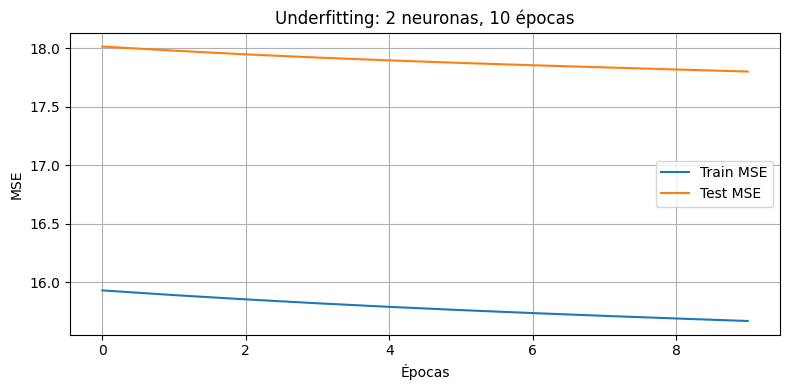

In [24]:
# UNDERFITTING
modelo_under = MLP(input_dim=4, hidden_dim=2, output_dim=1)                      # Crea una red MLP con muy baja capacidad: solo 2 neuronas ocultas
modelo_under, train_losses_under, test_losses_under = entrenar_MLP(              # Entrena el modelo con muy pocas épocas (10), lo que impide que aprenda bien
    modelo_under,
    X_train_tensor, y_train_tensor,
    X_test_tensor, y_test_tensor,
    n_epochs=10,                                                                 # Pocas épocas
    learning_rate=0.01,                                                          # Tasa de aprendizaje estándar
    weight_decay=0.0,                                                            # Sin regularización
    verbose=True                                                                 # Muestra el progreso del entrenamiento
)
# Grafica las pérdidas de entrenamiento y prueba para observar el subajuste
graficar_perdidas(train_losses_under, test_losses_under, titulo="Underfitting: 2 neuronas, 10 épocas")


- ### ***RENDIMIENTO ACEPTABLE MLP:***


---
En este bloque se configura el entrenamiento del modelo para obtener un rendimiento equilibrado y satisfactorio.

Se incrementa la capacidad del modelo utilizando 30 neuronas en la capa oculta, lo cual le permite capturar relaciones no lineales más complejas entre las variables y se entrena durante 150 épocas, otorgando tiempo suficiente para el aprendizaje; se aplica regularización (weight decay) para disminuir el sobreajuste. Se grafican las pérdidas para evaluar si el modelo mantiene un error bajo tanto en el conjunto de entrenamiento como en el de prueba.



Época 15/150 - Train MSE: 13.9758, Test MSE: 15.2378
Época 30/150 - Train MSE: 12.6390, Test MSE: 13.0433
Época 45/150 - Train MSE: 11.6190, Test MSE: 11.6150
Época 60/150 - Train MSE: 10.3515, Test MSE: 10.1545
Época 75/150 - Train MSE: 8.4439, Test MSE: 8.2583
Época 90/150 - Train MSE: 6.2676, Test MSE: 6.0573
Época 105/150 - Train MSE: 4.1864, Test MSE: 4.0720
Época 120/150 - Train MSE: 2.7570, Test MSE: 2.7126
Época 135/150 - Train MSE: 1.9611, Test MSE: 1.9303
Época 150/150 - Train MSE: 1.5521, Test MSE: 1.5066


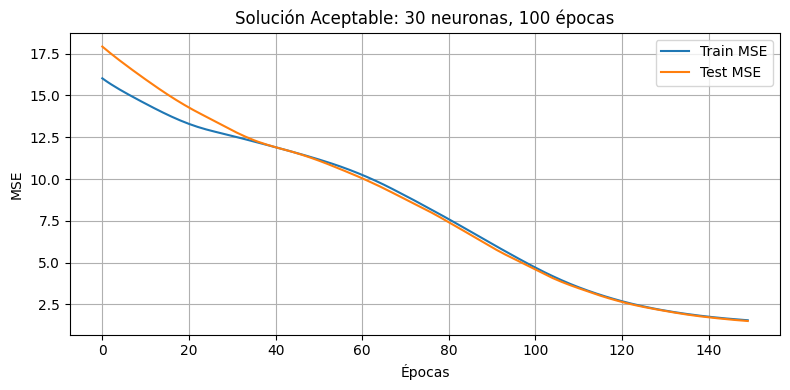

In [25]:
set_seed(42)  # Fijar la semilla asegura resultados reproducibles

# CASO DE SOLUCIÓN ACEPTABLE
modelo_ok = MLP(input_dim=4, hidden_dim=30, output_dim=1)                 # Se crea una red MLP con 30 neuronas en la capa oculta, lo cual le da buena capacidad de aprendizaje
modelo_ok, train_losses_ok, test_losses_ok = entrenar_MLP(
    modelo_ok,
    X_train_tensor, y_train_tensor,
    X_test_tensor, y_test_tensor,
    n_epochs=150,                                                         # Más épocas para mejor convergencia
    learning_rate=0.01,                                                   # Tasa de aprendizaje estándar
    weight_decay=1e-3,                                                    # Regularización L2 para reducir overfitting
    verbose=True                                                          # Muestra progreso del entrenamiento
)
# Visualización de la evolución del error en entrenamiento y prueba
graficar_perdidas(train_losses_ok, test_losses_ok, titulo="Solución Aceptable: 30 neuronas, 100 épocas")


- ### ***OVERFITING MLP:***


---
Lo que se busca ahora es configurar una red MLP con alta capacidad de representación y muchas épocas de entrenamiento, con el propósito de generar un caso claro de overfitting (sobreajuste).

Se utilizan 200 neuronas en la capa oculta (lo que da lugar a un modelo muy complejo) y se entrena durante 1000 épocas. Además, no se aplica regularización (weight_decay=0.0), lo que permite que el modelo aprenda incluso el ruido presente en los datos de entrenamiento.

El resultado fue el esperado, un muy bajo error en entrenamiento pero un error mayor o estancado en el conjunto de prueba, lo cual indica que el modelo no generaliza bien. La visualización de las curvas de pérdida permite identificar fácilmente este comportamiento.


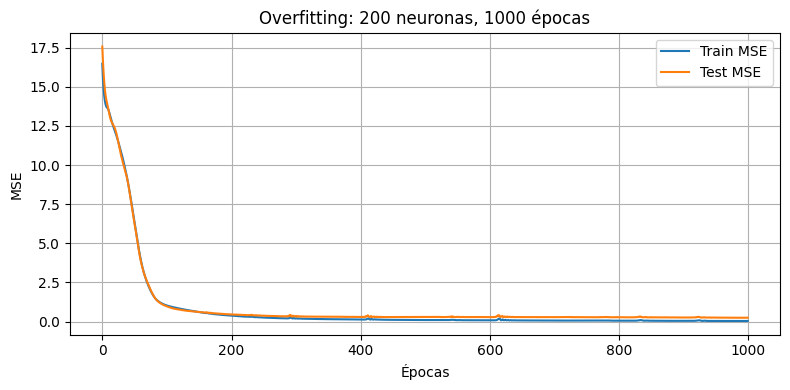

In [26]:
set_seed(42)

# CASO DE OVERFITTING
modelo_over = MLP(input_dim=4, hidden_dim=200, output_dim=1)             # Se crea una red MLP con 200 neuronas ocultas → modelo muy complejo
modelo_over, train_losses_over, test_losses_over = entrenar_MLP(
    modelo_over,
    X_train_tensor, y_train_tensor,
    X_test_tensor, y_test_tensor,
    n_epochs=1000,                                                       # Mucho entrenamiento → alto riesgo de memorizar
    learning_rate=0.01,                                                  # Tasa estándar
    weight_decay=0.0,                                                    # Sin regularización L2 → favorece el sobreajuste
    verbose=False                                                        # Evita imprimir cada época
)
# Visualización de la pérdida en entrenamiento y prueba
graficar_perdidas(train_losses_over, test_losses_over, titulo="Overfitting: 200 neuronas, 1000 épocas")


# **3. Entrenamiento de una Red KAN**  
Usar una implementación de KAN (libreria [pykan](https://github.com/KindXiaoming/pykan)).  

**Configuraciones a probar:**  
1. **Underfitting:**  
   - Red muy simple (ej: 1-2 neuronas por capa).  
   - Poca capacidad de aproximación.  

2. **Solución Aceptable:**  
   - Arquitectura equilibrada (ej: 4-5 neuronas por capa).  
   - Ajuste fino de hiperparámetros.  

3. **Overfitting:**  
   - Red muy profunda o con demasiadas neuronas.  
   - Entrenamiento prolongado sin early stopping.  

**Visualización:**  
- Graficar la función aprendida por KAN vs. los datos reales (en 2D si se proyecta una feature).  



# ***- Instalación de la librería pykan***

In [28]:
!pip install pykan


- ***Instalación de libreías y definición de la funcion de entrenamiento:***


---


Aqupi se define la función entrenar_KAN, encargada de entrenar una red Kolmogorov–Arnold Network (KAN) sobre un conjunto de datos de regresión.

La función recibe el modelo, los datos de entrenamiento y prueba, el número de épocas y la tasa de aprendizaje. Internamente, emplea el optimizador Adam y la función de pérdida MSE (Mean Squared Error). Durante cada época, se realiza un ciclo estándar de entrenamiento: se calcula la salida del modelo, se evalúa la pérdida, se propaga hacia atrás el gradiente (.backward()), y se actualizan los pesos del modelo.

Además, se evalúa el modelo sobre el conjunto de prueba sin actualizar sus parámetros (torch.no_grad()). Las pérdidas de entrenamiento y prueba se almacenan en listas para análisis posterior. Se imprime información de progreso cada cierto número de épocas si se activa verbose.

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from kan import KAN


def entrenar_KAN(model, X_train, y_train, X_test, y_test,                 # Función para entrenar una red KAN
                 n_epochs=100, learning_rate=1e-2, verbose=True):

    criterion = nn.MSELoss()                                              # Función de pérdida: error cuadrático medio
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)          # Optimizador Adam para ajustar los parámetros del modelo
    # Listas para registrar pérdidas en entrenamiento y prueba
    train_losses = []
    test_losses = []
    # Bucle principal de entrenamiento
    for epoch in range(n_epochs):
        model.train()                                                     # Modo entrenamiento: activa dropout/batchnorm si hay
        optimizer.zero_grad()                                             # Reinicia gradientes acumulados
        pred = model(X_train)                                             # Predicción del modelo sobre datos de entrenamiento
        loss = criterion(pred, y_train)                                   # Cálculo de la pérdida entre la predicción y el valor real
        loss.backward()                                                   # Retropropagación del error
        optimizer.step()                                                  # Actualización de los parámetros
        train_losses.append(loss.item())                                  # Almacenar pérdida de entrenamiento

        model.eval()                                                      # Evaluación del modelo en modo prueba (sin gradientes)
        with torch.no_grad():
            pred_test = model(X_test)
            test_loss = criterion(pred_test, y_test).item()
            test_losses.append(test_loss)

        if verbose and (epoch+1) % max(1, n_epochs // 10) == 0:           # Mostrar progreso cada n_epochs // 10
            print(f"Época {epoch+1}/{n_epochs} - Train MSE: {loss.item():.4f}, Test MSE: {test_loss:.4f}")

    return model, train_losses, test_losses




- ***Graficar puntos relaes vs predicciones:***


---


Esta función graficar_puntos permite visualizar gráficamente cómo el modelo ha aprendido a aproximar la relación entre una de las características de entrada y el valor objetivo (target).

La visualización se limita a una sola característica (especificada por feature_index), lo cual es útil para explorar el comportamiento  con respecto a esa variable individual.

La función desactiva el modo de entrenamiento (eval()) y los gradientes (no_grad()), predice con el modelo, y finalmente traza los valores reales del target frente a la característica elegida, comparándolos con las predicciones del modelo. Esto permite evaluar visualmente qué tan bien el modelo está ajustando la relación entre esa característica y el objetivo

In [30]:
# Función para graficar la función aprendida por el modelo con respecto a una sola característica
def graficar_puntos(model, X_tensor, y_tensor, feature_index=0, titulo=""):
    model.eval()                                                     # Pone el modelo en modo evaluación (desactiva dropout, batchnorm, etc.)

    with torch.no_grad():                                            # Desactiva el cálculo del gradiente (más eficiente y seguro en inferencia)
        y_pred = model(X_tensor).squeeze()                           # Predicciones del modelo, aplastadas a 1D si es necesario
    x_vals = X_tensor[:, feature_index].numpy()                      # Extraer la columna correspondiente a la característica elegida
    # Extraer valores reales del target y predicciones en formato NumPy
    y_true = y_tensor.squeeze().numpy()                              # Valores reales
    y_pred_np = y_pred.numpy()                                       # Predicciones del modelo

    plt.figure(figsize=(8, 5))                                       # Crear la figura
    plt.scatter(x_vals, y_true, label='Real', alpha=0.5)             # Dibujar puntos reales
    plt.scatter(x_vals, y_pred_np, label='KAN Predicción', alpha=0.5)# Dibujar puntos predichos por el modelo
    # Etiquetas y título del gráfico
    plt.xlabel(f'Feature {feature_index}')
    plt.ylabel('Target')
    plt.title(titulo)
    plt.legend()
    plt.grid(True)
    plt.show()                                                        # Mostrar el gráfico

- ***Graficar las funciones aprendidas por el modelo.***


---


Se define la función graficar_funciones_aprendidas, que permite visualizar de forma individual el efecto de cada una de las características (features) sobre la predicción del modelo KAN. Para cada una de las variables de entrada, la función genera una gráfica en la que se representa cómo varía la predicción del modelo al modificar únicamente esa característica, manteniendo las demás constantes en su valor medio.

Esto se logra mediante la creación de una grilla de valores para la feature actual, mientras que el resto se fijan al promedio del conjunto de entrenamiento. Luego, el modelo KAN predice los valores correspondientes y se compara con los datos reales proyectados sobre esa misma característica.









In [31]:
def graficar_funciones_aprendidas(model, X_tensor, y_tensor, titulos=None):
    model.eval()                                                                 # Poner el modelo en modo evaluación
    num_features = X_tensor.shape[1]                                             # Número de características (columnas)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))                             # Crear una figura con subplots 2x2
    axes = axes.flatten()                                                        # Convertimos a arreglo 1D para iterar fácilmente

    X_mean = X_tensor.mean(dim=0).numpy()                                        # Calcular la media de cada feature (para fijar las otras

    for i in range(num_features):                                                # Iterar sobre cada feature para graficar
        # Crear una grilla de valores entre el mínimo y máximo de la característica i
        x_min = X_tensor[:, i].min().item()
        x_max = X_tensor[:, i].max().item()
        x_grid = np.linspace(x_min, x_max, 200).reshape(-1, 1)

        # Crear una entrada de prueba manteniendo las otras features constantes (X_mean)
        X_input = np.tile(X_mean, (200, 1))                                      # Repetimos el vector promedio
        X_input[:, i] = x_grid[:, 0]                                             # Sustituimos la columna i por la grilla

        # Predicción del modelo sobre esos datos generados
        X_input_tensor = torch.tensor(X_input, dtype=torch.float32)
        with torch.no_grad():
            y_pred_grid = model(X_input_tensor).squeeze().numpy()

        # Proyección de datos reales sobre esa característica
        x_real = X_tensor[:, i].numpy()
        y_real = y_tensor.squeeze().numpy()

        # Graficar en el subplot correspondiente
        ax = axes[i]
        ax.scatter(x_real, y_real, label='Real', alpha=0.3)
        ax.plot(x_grid, y_pred_grid, label='KAN (función aprendida)', color='red', linewidth=2)
        ax.set_xlabel(f'Feature {i}')
        ax.set_ylabel('Target')
        ax.set_title(titulos[i] if titulos else f'Feature {i}')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()                                                           # Ajuste para evitar solapamientos
    plt.show()                                                                   # Mostrar la figura





- ## ***UNDERFITTING - KAN:***


---
Se implementa y evalúa un modelo KAN configurado intencionalmente para representar un caso de underfitting. Se usa una arquitectura mínima (width=[4, 1, 1]), lo cual implica una única neurona en la capa intermedia, con una grilla de activación limitada a 4 nodos. Así se limita la capacidad del modelo para capturar relaciones complejas en los datos. Luego el modelo se entrena durante 60 épocas con una tasa de aprendizaje de 0.01.

Durante el entrenamiento, se registran las pérdidas (errores MSE) en el conjunto de entrenamiento y en el de prueba.

Luego, se grafican estas pérdidas para analizar la evolución del aprendizaje y se visualiza cómo la red KAN ajusta sus predicciones con respecto a los datos reales, tanto sobre una única característica (feature_index=0) como sobre todas las variables individualmente, mediante las funciones graficar_puntos y graficar_funciones_aprendidas. Estas visualizaciones permiten detectar la incapacidad del modelo para aproximar adecuadamente la función objetivo, visualizando el underfitting.



checkpoint directory created: ./model
saving model version 0.0
Época 6/60 - Train MSE: 16.2874, Test MSE: 18.3995
Época 12/60 - Train MSE: 16.0556, Test MSE: 18.1359
Época 18/60 - Train MSE: 15.7871, Test MSE: 17.8310
Época 24/60 - Train MSE: 15.4405, Test MSE: 17.4133
Época 30/60 - Train MSE: 14.8931, Test MSE: 16.7876
Época 36/60 - Train MSE: 14.1948, Test MSE: 15.9667
Época 42/60 - Train MSE: 13.3275, Test MSE: 14.8549
Época 48/60 - Train MSE: 12.3927, Test MSE: 13.6746
Época 54/60 - Train MSE: 11.4643, Test MSE: 12.5217
Época 60/60 - Train MSE: 10.5847, Test MSE: 11.4262


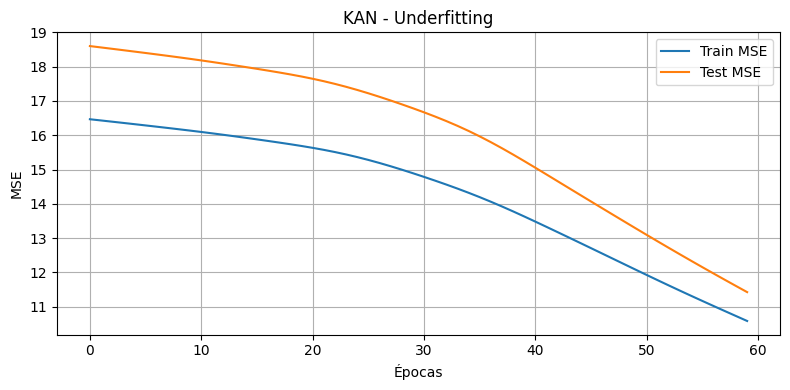

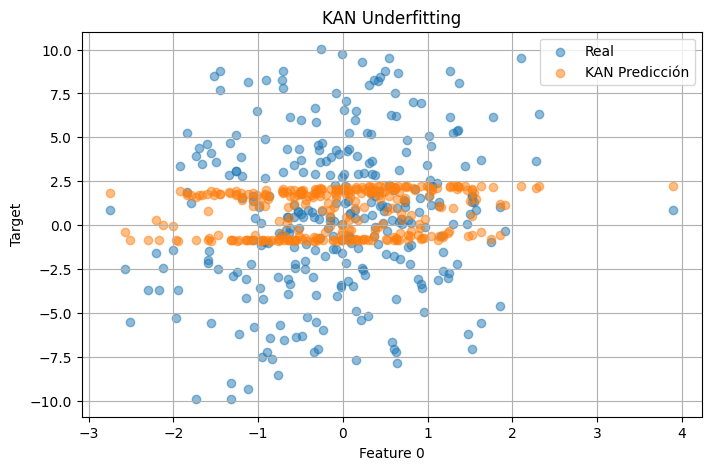

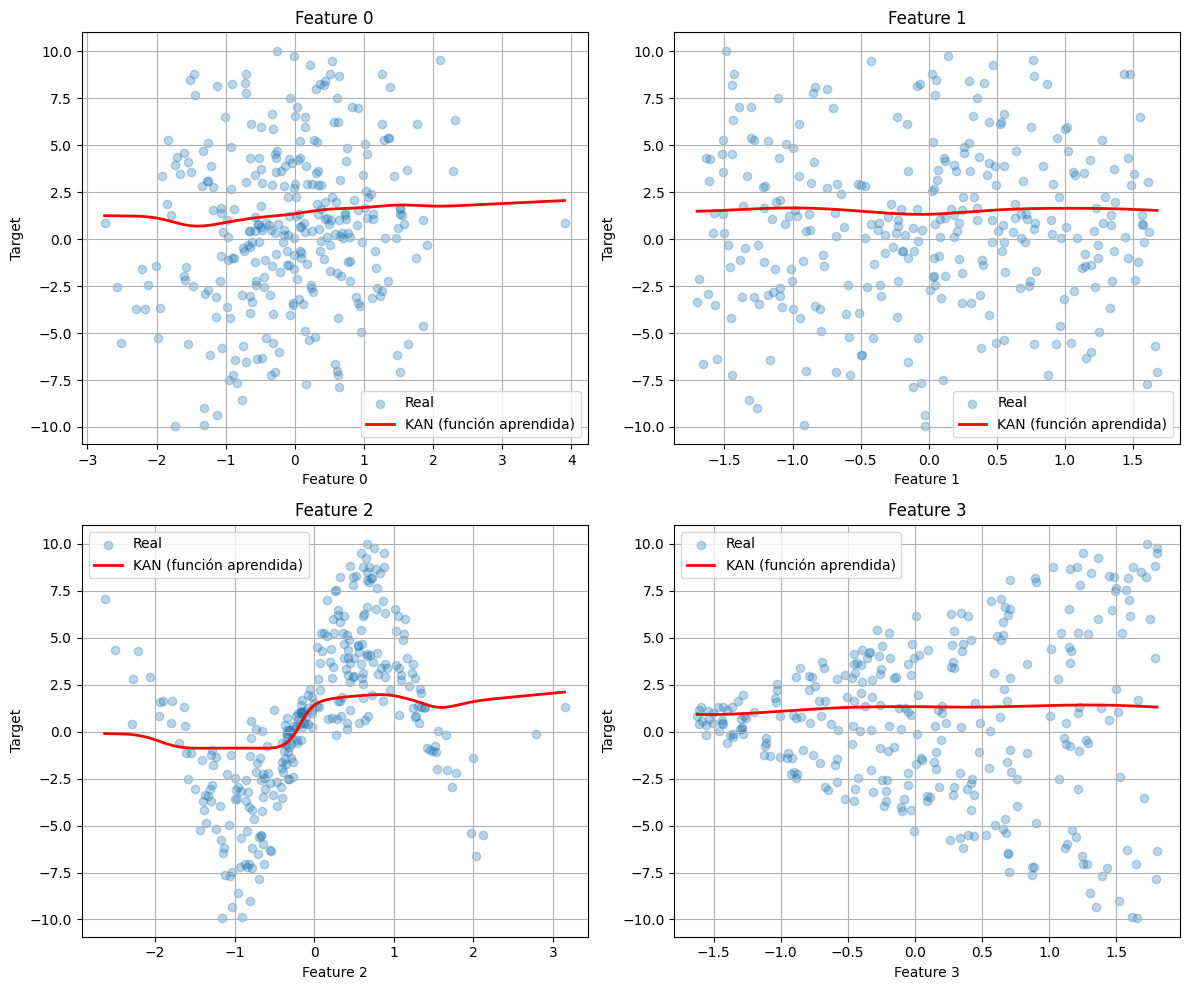

In [35]:
kan_under = KAN(width=[4, 1, 1], grid=4)
kan_under, loss_train_under, loss_test_under = entrenar_KAN(
    kan_under, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    n_epochs=60, learning_rate=0.01, verbose=True
)
graficar_perdidas(loss_train_under, loss_test_under, "KAN - Underfitting")
graficar_puntos(kan_under, X_test_tensor, y_test_tensor, feature_index=0, titulo="KAN Underfitting")
graficar_funciones_aprendidas(kan_under, X_test_tensor, y_test_tensor,
    titulos=["Feature 0", "Feature 1", "Feature 2", "Feature 3"])


- ##  ***RENDIMIENTO ACEPTABLE - KAN:***


---

Se define ahora una configuración para el entrenamiento del modelo diseñada para lograr una solución aceptable al problema de regresión. En este caso, la red tiene una arquitectura más compleja que en el ejemplo de underfitting, con una capa oculta de 4 unidades (width=[4, 4, 1]) y una grilla más densa (grid=8), lo que le otorga mayor capacidad de modelado para capturar relaciones no lineales entre las variables de entrada y el target.

El modelo se entrena durante 100 épocas con una tasa de aprendizaje de 0.01, utilizando la función entrenar_KAN, que retorna el modelo entrenado y los valores de pérdida (MSE) tanto para el conjunto de entrenamiento como de prueba.

Posteriormente, se visualizan las pérdidas con graficar_perdidas, lo cual permite evaluar si el modelo ha aprendido de forma estable. Además, se grafican las predicciones proyectadas sobre una sola característica (feature_index=0) con graficar_puntos, y se muestran las funciones aprendidas por la red para cada característica individual mediante graficar_funciones_aprendidas.

Este análisis combinado permite verificar que el modelo se ajusta razonablemente a los datos sin caer en underfitting ni overfitting, alcanzando así una solución balanceada.


checkpoint directory created: ./model
saving model version 0.0
Época 10/100 - Train MSE: 15.6079, Test MSE: 17.6442
Época 20/100 - Train MSE: 14.1216, Test MSE: 15.9019
Época 30/100 - Train MSE: 11.7203, Test MSE: 13.1571
Época 40/100 - Train MSE: 8.8584, Test MSE: 9.7247
Época 50/100 - Train MSE: 6.7926, Test MSE: 6.9446
Época 60/100 - Train MSE: 4.9346, Test MSE: 4.8683
Época 70/100 - Train MSE: 3.0480, Test MSE: 3.1074
Época 80/100 - Train MSE: 1.8964, Test MSE: 1.9649
Época 90/100 - Train MSE: 1.3698, Test MSE: 1.4138
Época 100/100 - Train MSE: 1.1090, Test MSE: 1.1711


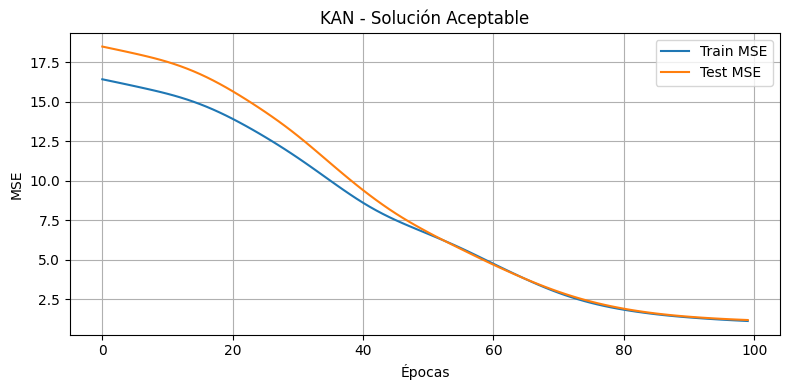

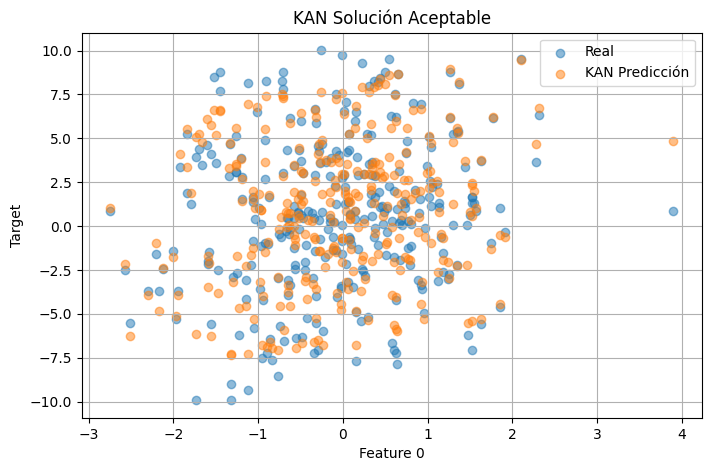

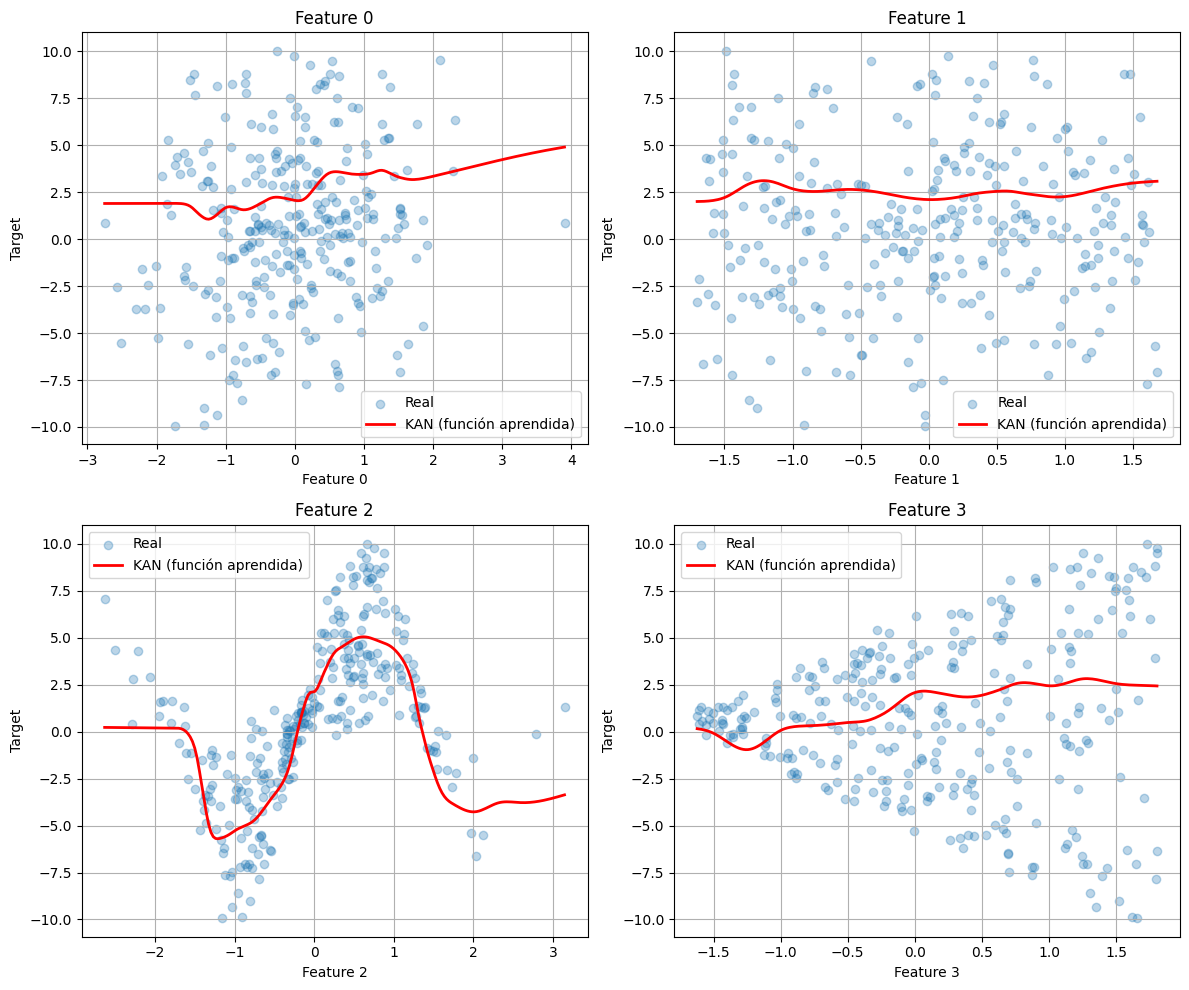

In [32]:
kan_ok = KAN(width=[4, 4, 1], grid=8)                                     # Se define una red KAN con 4 entradas, 4 nodos ocultos y 1 salida
                                                                          # La grilla de activación tiene 8 puntos, lo que permite representar funciones no lineales con mayor detalle.
kan_ok, loss_train_ok, loss_test_ok = entrenar_KAN(
    kan_ok, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, # Se entrena el modelo KAN con los datos de entrenamiento y prueba por 100 épocas.
    n_epochs=100, learning_rate=0.01, verbose=True                        # Se utiliza una tasa de aprendizaje de 0.01.
)                                                                         # Se devuelve el modelo entrenado y las listas con las pérdidas MSE por época para entrenamiento y prueba.

graficar_perdidas(loss_train_ok, loss_test_ok, "KAN - Solución Aceptable")# Se grafica la evolución del error cuadrático medio (MSE) para entrenamiento y test.

graficar_puntos(kan_ok, X_test_tensor, y_test_tensor, feature_index=0, titulo="KAN Solución Aceptable") # Se grafican las predicciones del modelo sobre el conjunto de test en función de la primera variable (feature 0).

graficar_funciones_aprendidas(kan_ok, X_test_tensor, y_test_tensor,       # Se grafican las funciones aprendidas por el modelo para cada una de las 4 variables de entrada,
    titulos=["Feature 0", "Feature 1", "Feature 2", "Feature 3"])         # manteniendo las otras constantes.




- ## ***OVERFITTING - KAN:***


---
Por último se entrena una red KAN con una arquitectura sobredimensionada, compuesta por múltiples capas ocultas con un número elevado de unidades (width=[4, 10, 5, 4, 1]) y una grilla muy densa (grid=16); buscando un caso de overfitting, en el que el modelo aprende demasiado bien los patrones específicos del conjunto de entrenamiento, pero pierde capacidad de generalización hacia nuevos datos.

El modelo se entrena durante 300 épocas usando una tasa de aprendizaje de 0.01, lo que, combinado con la alta complejidad del modelo, permite observar cómo el error en el conjunto de entrenamiento puede disminuir significativamente, mientras que el error de prueba se estabiliza o incluso aumenta.

La función graficar_perdidas permite visualizar esta divergencia entre el desempeño en entrenamiento y prueba. Posteriormente, graficar_puntos muestra cómo las predicciones del modelo sobre una sola característica (feature 0) se ajustan a los datos reales, y graficar_funciones_aprendidas revela funciones complejas aprendidas por el modelo para cada variable.

Esta configuración hace notar la necesidad de regularizar o simplificar modelos cuando su capacidad excede lo necesario para el problema.




checkpoint directory created: ./model
saving model version 0.0
Época 30/300 - Train MSE: 8.0358, Test MSE: 9.1955
Época 60/300 - Train MSE: 0.5388, Test MSE: 1.9465
Época 90/300 - Train MSE: 0.0344, Test MSE: 1.4489
Época 120/300 - Train MSE: 0.0066, Test MSE: 1.5263
Época 150/300 - Train MSE: 0.0037, Test MSE: 1.5459
Época 180/300 - Train MSE: 0.0008, Test MSE: 1.5686
Época 210/300 - Train MSE: 0.0068, Test MSE: 1.5969
Época 240/300 - Train MSE: 0.0002, Test MSE: 1.5901
Época 270/300 - Train MSE: 0.0011, Test MSE: 1.5834
Época 300/300 - Train MSE: 0.0004, Test MSE: 1.6010


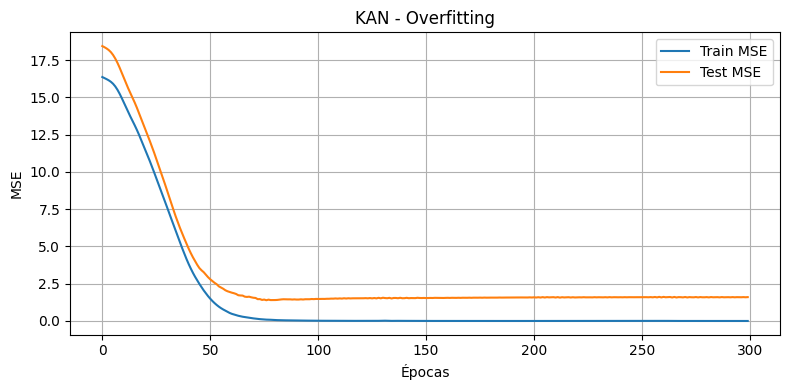

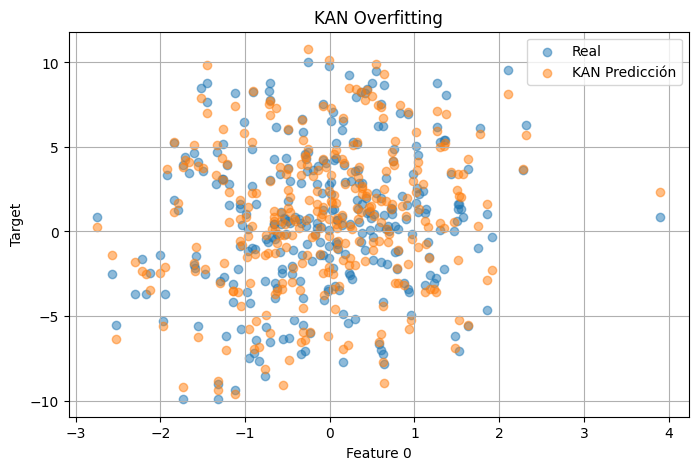

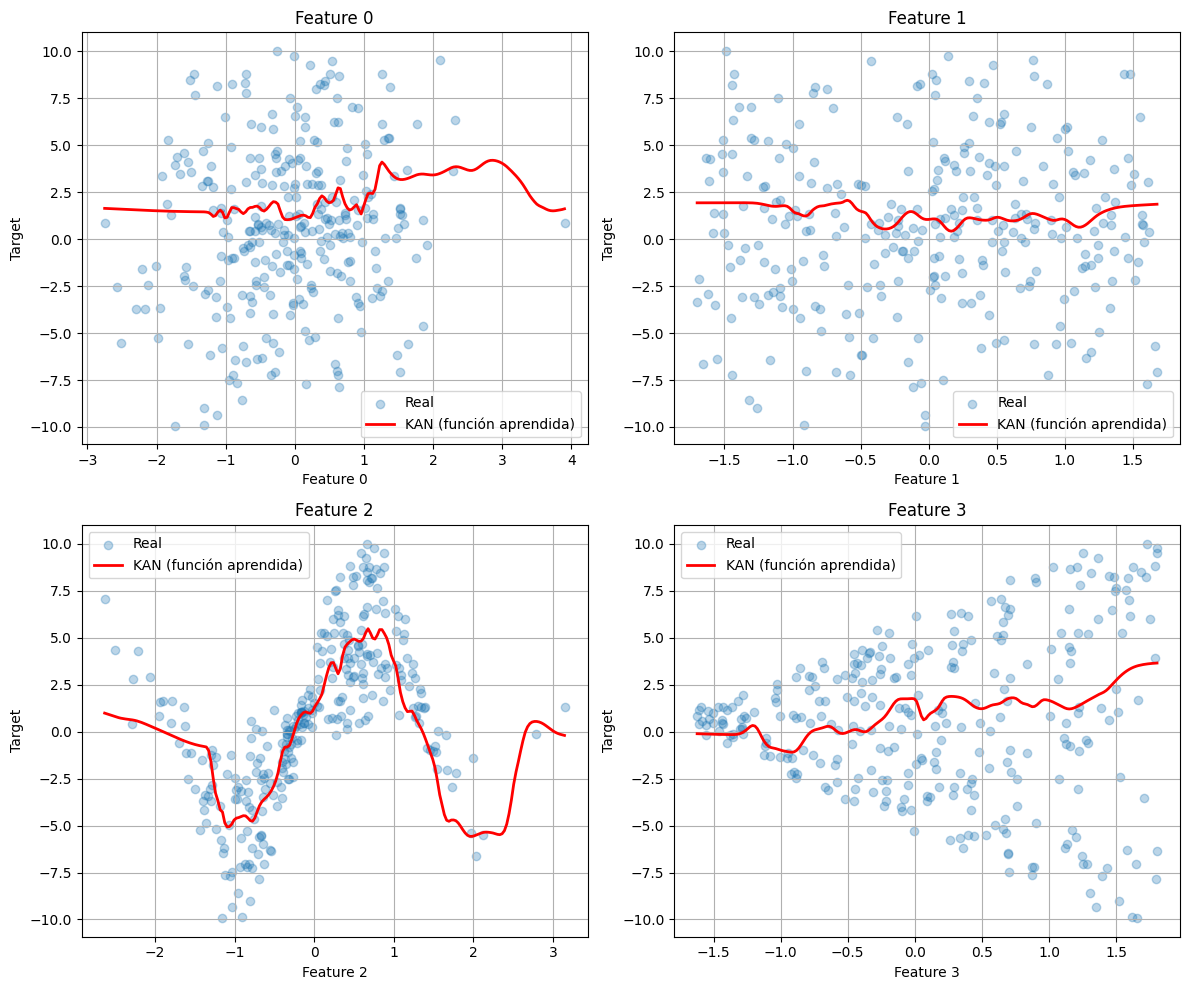

In [18]:

kan_over = KAN(width=[4, 10, 5, 4, 1], grid=16)
kan_over, loss_train_over, loss_test_over = entrenar_KAN(
    kan_over, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    n_epochs=300, learning_rate=0.01, verbose=True
)
graficar_perdidas(loss_train_over, loss_test_over, "KAN - Overfitting")
graficar_puntos(kan_over, X_test_tensor, y_test_tensor, feature_index=0, titulo="KAN Overfitting")
graficar_funciones_aprendidas(kan_over, X_test_tensor, y_test_tensor,
    titulos=["Feature 0", "Feature 1", "Feature 2", "Feature 3"])



# **4. Conclusiones y Análisis**  
- Comparar **MLP vs KAN** en términos de:  
  - Capacidad de aproximación.  
  - Sensibilidad al overfitting/underfitting.  
  - Interpretabilidad (KAN permite visualizar funciones base).  
- Discutir:  
  - ¿Cuál modelo es más flexible?  
  - ¿En qué casos conviene usar KAN?  



4 a) Capacidad de aproximación:

MLP Underfitting: Demuestra una alta pérdida en test y train, muy poca capacidad para ajustarse adecuadamente a los datos.

MLP Aceptable: Buen ajuste en entrenamiento y testeo. Es un modelo suficientemente expresivo que  permite capturar relaciones no lineales más complejas entre las variables demostrando errores bajos en prueba y testeo.

MLP Overfitting: La pérdida de entrenamiento es baja, pero en testeo se estanca o sube.el modelo no generaliza bien y se aprende demasiado los datos de entrenamiento incluso el ruido.

KAN Underfitting: Tiene una pérdida alta y una pobre convergencia. La	red tan pequeña ([4,1,1]) con grid chico (4) no capta bien la función, no logrando generalizar.

KAN Aceptable: Aquí se observa un buen ajuste y una buena generalizació. La red [4,4,1] con grid 8 logra flexibilidad y generalización sin sobreajuste.

KAN Overfitting: Aquí la pérdida de entrenamiento es muy baja, pero la de testeo se estanca/sube. La red profunda ([4,10,5,4,1]) y un grid muy denso (16) hace que aprenda demasiado bien los patrones específicos del conjunto de entrenamiento, pero pierda capacidad de generalización hacia nuevos datos. Sobreajuste claro.

A modo de conclusión: Ambos modelos tienen buena capacidad de aproximación, pero KAN logra un rendimiento comparable o mejor con menos parámetros (por ejemplo, en la solución aceptable). Esto se debe a su estructura más adaptativa basadas en las funciones que ajusta y aprende.

4 b) Sensibilidad


Da la sensación de que MLP	requiere un ajuste más fino de hiperparámetros, es muy sensible al tamaño de la red y a laregularización.	El modelo llega fácilmente al overfitting sin weight decay.

KAN	También puede generar overfitting si es muy ancho/profundo, pero es más controlable gracias al grid.	La utilización de funciones base por dimensión actúa en cierta forma como una regularización durante el aprendizaje.

KAN parece más robusto a configuraciones medianamente complejas. MLP requiere mucho cuidado con regularización.

4 c) Interpretabilidad

MLP: Este modelo termina siendo una caja negra total, donde las neuronas aprenden representaciones internas que no son interpretables.

KAN: Puede visualizar funciones aprendidas por variable, gracias a las funciones base por dimensión (como splines). Esto permite entender cómo cada variable contribuye al resultado.


4 d) ¿Cuál modelo es más flexible?

En cuanto a la capacidad de modelar funciones muy complejas, ambos modelos pueden lograrlo con configuraciones adecuadas. Ahora si se tiene en cuenta la
robustez al cambio de estructura	KAN (puede aumentar grid o capas suavemente)

Y si miramos la interpretabilidad y el ajuste local por dimensión	KAN esta por encima. Por esto podría decir que KAN es más flexible en términos estructurales y de interpretación, sin perder potencia de predicción.

4 e) ¿Cuándo conviene usar KAN?

Creo que usar KAN es recomendable cuando lo que se busca es "interpretabilidad" (cómo afecta cada variable).

Creo también que puede ser útil cuando se tienen datos tabulares con pocas dimensiones (como este caso, con 4 features).

Cuando lo que se busca es control sobre overfitting sin depender exclusivamente de una regularización.

En cambio podría ser menos útil tal vez cuando se trabaja con datos altamente dimensionales o secuenciales (donde MLP o redes más profundas podrían escalar mejor).O cuando no se necesita interpretabilidad y lo que se prefiere es rendimiento puro en calgún ambiente complejos.

## **5- Referencias**

***Prompt en chat GPT:***

---



1.   "Especifica la manera correcta y completa de lograr reproducibilidad (a través de SEED) en la generación de un dataset sintético y entrenamiento de un modelo MLP y KAN para un problema de regresión"
2.   "Explica porqué al graficar la fución aprendida por el modelo KAN en un dataset de 4 features y graficando en dos dimensiones, no consigo ver que sea representativa de los puntos reales?"
3.    "Necesito entonces graficar las 4 funciones aprendidas, una para cada variable, manteniendo las demas constantes. y mostrarlas en 4 graficos dispuestos en una matris de 2x2 para mejor visualizacion".

***Material propuesto por la materia:***

---


1.  Notebooks informativos
2.  Tutoriales de pytorch









